# **PART I: Build, Train, and Test an LSTM with Time Series Data**

In [93]:
# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
%matplotlib inline


In [94]:
import tensorflow as tf
print(tf.__version__)

2.17.0


In [95]:
# For timeseries RNN LSTM NN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [96]:
# Importing Keras : TimeseriesGenerator
# Produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

#Import Keras: MinMaxScaler
# Used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

## Dataset : TSLA (Tesla Stock: 2022 - 2024)

In [97]:
dir_path_dataset_1= 'TSLA_HistoricalData_2022_2024_V5.csv'

## **Loading Dataset**

In [98]:

df = pd.read_csv(dir_path_dataset_1)

In [99]:
df.replace({'\$': ''}, regex=True, inplace=True)

df[['Close', 'Open', 'High', 'Low']] = df[['Close', 'Open', 'High', 'Low']].astype(float)

In [100]:
# Standardize the Date column
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Sort
df.sort_values(by="Date", inplace=True)

In [101]:
# reset the indexx after sorting
df.reset_index(drop=True, inplace=True)

In [102]:
# Keep only the first 503 rows
df = df.iloc[:503]

# Check the updated dataframe size
print(len(df))

503


In [103]:
df.head()

,Date,Close,Volume,Open,High,Low
0,2022-01-03,399.9266,104686060,382.5833,400.3566,378.6800
1,2022-01-04,383.1966,100248280,396.5166,402.6666,374.3500
2,2022-01-05,362.7066,80119808,382.2166,390.1133,360.3367
3,2022-01-06,354.9000,90336489,359.0000,362.6666,340.1666
4,2022-01-07,342.3200,84164768,360.1233,360.3099,336.6666


## EDA

In [104]:
df.shape

(503, 6)

In [105]:
df.dtypes

Date      datetime64[ns]
Close            float64
Volume             int64
Open             float64
High             float64
Low              float64
dtype: object

In [106]:
#Statistical Summary
df.describe()

,Date,Close,Volume,Open,High,Low
count,503,503.000000,5.030000e+02,503.000000,503.000000,503.000000
mean,2023-01-02 02:37:27.316103424,240.342014,1.121174e+08,240.679142,246.157742,234.657278
min,2022-01-03 00:00:00,108.100000,4.186474e+07,103.000000,111.750000,101.810000
25%,2022-07-05 12:00:00,197.475000,8.207969e+07,198.235000,202.900000,193.480000
50%,2023-01-03 00:00:00,241.866600,1.046861e+08,242.740000,247.140000,236.976600
75%,2023-07-05 12:00:00,276.025000,1.355520e+08,277.796650,283.315000,270.656650
max,2024-01-03 00:00:00,399.926600,3.065906e+08,396.516600,402.666600,378.680000
std,NaN,55.276085,4.126551e+07,55.733206,56.749472,54.231924


## **Keeping Only "Close" (for Closing Price) and Filter Out other fields**
Note: this project focuses only on the closing price

In [107]:
# df = df_ALL.iloc[:,4:5]
df = df[['Close']]

In [108]:
df.head()

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200


<Axes: >

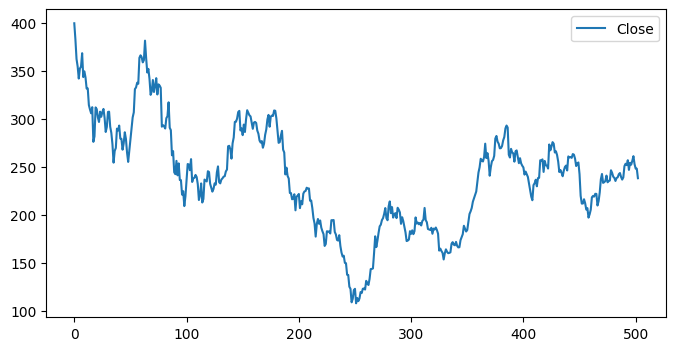

In [109]:
df.plot(figsize=(8,4))

## **Length of Input Time Series - Number of Input Time Steps**

In [110]:
# Setting the length of the input sequence
# i.e., the number of time series steps that are used to predict the future one
# Currently using 60 historical data points to predict the next one
# It means 60 consecutive closing prices will be used to predict the next one
length60 = 60

In [111]:
length60

60

## **Time Series Dataset: Train/test Split**

In [112]:
len(df)

503

In [113]:
# Split the DataFrame into training, validation, and test sets
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = len(df) - train_size - val_size

In [114]:
# Set percentage of data used for testing

test_percent = 0.1

In [115]:
# Number of data points reserved for testing the model 
# 10% of the original dataset

len(df)*test_percent

50.300000000000004

## **Splitting Data into Train/Test**

In [116]:
# We need to find the length of the testing dataset (We have already done so above (about 50 data points for testing)

test_length = np.round(len(df)*test_percent)
test_length

50.0

In [117]:
# Testing data starts at this index

# test_start_index = int(len(df) - test_length)
split_index = int(len(df) - test_length)
split_index

453

In [118]:
# Creating seperate training/ testing datasets

# Training dataset : All the indices from start to split_index (excluding split_index)
data_train = df.iloc[: split_index]

#Testing dataset : All indices from split_index - length60 to the end of the dataframe
#split_index - length60 : Need the last 60 historical data points (belong to data_train) to predict the first data point of the data_test
data_test = df.iloc[split_index - length60 :]

In [119]:
data_train.head(5)

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200


In [120]:
data_train.tail()

,Close
448,253.92
449,254.85
450,242.68
451,220.11
452,211.99


In [121]:
data_test.head(5)

,Close
393,266.44
394,267.43
395,261.07
396,254.11
397,259.32


In [122]:
data_test.tail()

,Close
498,261.44
499,253.18
500,248.48
501,248.42
502,238.45


## **Normalizing the Data (Scale into range [0,1]**

In [123]:
#Creating a MnMaxScaler to normalize the data
scaler = MinMaxScaler()

In [124]:
#Converting the data to floats
# ONLY scaling the training data- not the testing data

# Training the scaler to perform the normalization
scaler.fit(data_train)

MinMaxScaler()

In [125]:
#Normalizing the training dataset
normalized_train = scaler.transform(data_train)

#Normalizing the testing dataset
normalized_test = scaler.transform(data_test)

## Creating TimeseriesGenerator for Training

In [126]:
#TimeseriesGenerator : Generating time series batches for training/testing

#Set the length of the input sequence as length60 (like above)
#batch_size : Number of time series samples in each batch
#Sample: A single time series input that has 60 historical data points
batch_size32 = 32

# Creating a TimeseriesGeneerator for training: train_tsGenerator
# to produce time series batches used to train the model
# TimeseriesGenerator (inputs, outputs, length, batch_size)
train_tsGenerator60 = TimeseriesGenerator(normalized_train, normalized_train, length=length60, batch_size=batch_size32)

In [127]:
len(normalized_train)

453

In [128]:
len(train_tsGenerator60)

13

In [129]:
# What does the first batch look like?
X,y = train_tsGenerator60[0]

In [130]:
print(X)

[[[1.        ]
  [0.94267144]
  [0.87245851]
  ...
  [0.78395869]
  [0.87670761]
  [0.88553716]]

 [[0.94267144]
  [0.87245851]
  [0.84570769]
  ...
  [0.87670761]
  [0.88553716]
  [0.87916352]]

 [[0.87245851]
  [0.84570769]
  [0.8025999 ]
  ...
  [0.88553716]
  [0.87916352]
  [0.86044247]]

 ...

 [[0.6298946 ]
  [0.68320229]
  [0.68429883]
  ...
  [0.61834665]
  [0.52863584]
  [0.54340488]]

 [[0.68320229]
  [0.68429883]
  [0.63056829]
  ...
  [0.52863584]
  [0.54340488]
  [0.46797173]]

 [[0.68429883]
  [0.63056829]
  [0.60844351]
  ...
  [0.54340488]
  [0.46797173]
  [0.46111835]]]


In [131]:
print(y)

[[0.87916352]
 [0.86044247]
 [0.86842666]
 [0.9379426 ]
 [0.87604523]
 [0.82407361]
 [0.83720949]
 [0.80092082]
 [0.74431186]
 [0.75689913]
 [0.79735706]
 [0.75467178]
 [0.77670541]
 [0.80395893]
 [0.74576238]
 [0.78183414]
 [0.77757339]
 [0.76954363]
 [0.63064847]
 [0.6364622 ]
 [0.63189339]
 [0.62418333]
 [0.66094044]
 [0.6681478 ]
 [0.71768646]
 [0.62706176]
 [0.61834665]
 [0.52863584]
 [0.54340488]
 [0.46797173]
 [0.46111835]
 [0.50862396]]


# **Build, Train and Test Model**

## Building LSTM Model

In [132]:
#Setting number of features
#Feature: Attribute/Variable of the dataset - used as predictors

#Only using one feature: Close price
n_features = 1

In [133]:
# Defining the model
model = Sequential()

# Adding on LSTM layer
# This layer has 50 LSTM cells
# Activation function: ReLU
# return_sequences = True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(60, activation='relu', return_sequences=True, input_shape=(length60, n_features)))

#Dropout layer 1
model.add(Dropout(0.2))

# Adding the 2nd LSTM layer
# return_sequences=True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(units=60, activation='relu', return_sequences=True))

#Dropout layer 2
model.add(Dropout(0.2))

#Adding the 3rd LSTM layer
model.add(LSTM(units=60, activation='relu', return_sequences=True))

#Dropout layer 3
model.add(Dropout(0.2))

#Adding the 4th LSTM layer
model.add(LSTM(units=60, activation='relu'))

#Adding a FC layer for the final prediction
model.add(Dense(1))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## **Compiling the model**

In [134]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

model.summary()
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 60)         │        14,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 60, 60)         │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60, 60)         │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 60)             │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,061 (398.68 KB)

 Trainable params: 102,061 (398.68 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## **Training (Fit) Model using fit_generator()**

In [135]:
# Training the model
# fit_generator is depricated for this version of tensorflow, so I ave used model.fit()
model.fit(train_tsGenerator60, epochs=100)

Epoch 1/100
 2/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.1959

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.1723
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0386
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0448
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0256
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0152
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0170
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0199
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0147
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0151
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0141
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0169
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0171
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0153
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0102
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0150
E

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0055
Epoch 82/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0051
Epoch 83/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0043
Epoch 84/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0038
Epoch 85/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0039
Epoch 86/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0041
Epoch 87/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0028
Epoch 88/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0037
Epoch 89/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0039
Epoch 90/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0048
Epoch 91/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0036
Epoch 92/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0038
Epoch 93/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0034
Epoch 94/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0054
Epoch 95/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 

## **Visualizing the model's performance after Training**

In [136]:
loss_history_keys = model.history.history.keys()

#model.history.history is a dict
# 'loss' : its key
# 'loss' : loss during training
loss_history_keys

dict_keys(['loss'])

<Axes: >

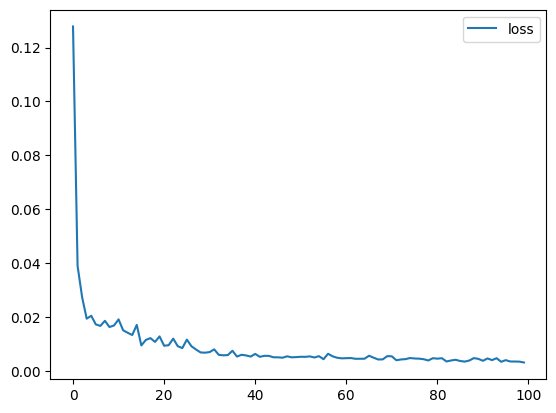

In [137]:
#Load the loss data (model.history.history) into a data frame
df_model_loss = pd.DataFrame(model.history.history)

#Visualize the loss data using DataFrame.plot()
df_model_loss.plot()

# **Prediction for Testing: Using TimeseriesGenerator**

## **Create TimeseriesGenerator for Testing**

In [138]:
# batch_size must be 1
batch_size1 = 1

# Create a TimeSeriesGenerator for testing: test_tsGenerator
test_tsGenerator60 = TimeseriesGenerator(normalized_test, normalized_test, length=length60, batch_size=batch_size1)

## **Predicting Future Data Points for Testing**

In [139]:
#model.predict_generator does not work with the latest version of tensorflow, so we use model.predict
normalized_prediction = model.predict(test_tsGenerator60)

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [140]:
#Prediction is a numpy 2D array with only one column

normalized_prediction

array([[0.46534237],
       [0.44493532],
       [0.42330122],
       [0.40241963],
       [0.38287106],
       [0.3653949 ],
       [0.34938496],
       [0.33503047],
       [0.3231686 ],
       [0.31577262],
       [0.31362852],
       [0.31622833],
       [0.32254544],
       [0.3311662 ],
       [0.3391223 ],
       [0.34523538],
       [0.35038576],
       [0.3570035 ],
       [0.3668066 ],
       [0.37847823],
       [0.39038128],
       [0.40133476],
       [0.41131806],
       [0.4193279 ],
       [0.42507234],
       [0.42876768],
       [0.4322278 ],
       [0.43598565],
       [0.4394407 ],
       [0.4419481 ],
       [0.4428492 ],
       [0.44255295],
       [0.4416335 ],
       [0.44096425],
       [0.44109878],
       [0.4415602 ],
       [0.44159666],
       [0.4412038 ],
       [0.4420733 ],
       [0.44517586],
       [0.4501818 ],
       [0.4569564 ],
       [0.46338466],
       [0.4691495 ],
       [0.47383717],
       [0.4778272 ],
       [0.48194638],
       [0.485

In [141]:
len(normalized_prediction)

50

In [142]:
# Converting normalized predictions back to the true values
prediction = scaler.inverse_transform(normalized_prediction)

In [143]:
print(len(prediction))

50


In [144]:
# Flattening all the 2D array

# data_train = data_train.reshape((-1))
# data_test = data_test.reshape((-1))
# prediction = prediction.reshape((-1))

prediction_index = np.arange(393, 393 + len(prediction), step=1)

#prediction_index = np.arange(599, 599 + len(prediction), step=1)

df_prediction = pd.DataFrame(data=prediction,index=prediction_index, columns=['Prediction'])



In [145]:
df_prediction

,Prediction
393,243.899277
394,237.943970
395,231.630554
396,225.536758
397,219.831955
398,214.731949
399,210.059830
400,205.870804
401,202.409195
402,200.250839


## **Visualizing the Prediction**

<Axes: >

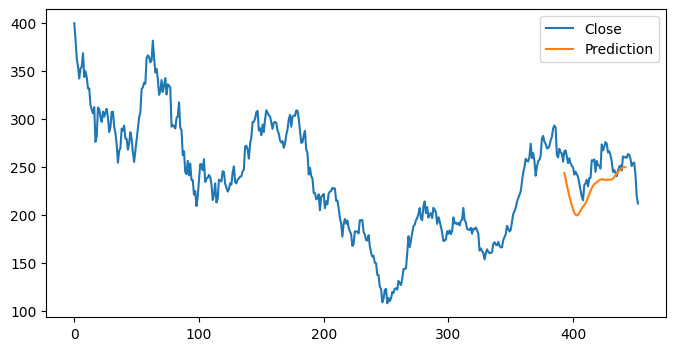

In [146]:
ax = data_train.plot()
df_prediction.plot(ax=ax, figsize=(8, 4))

# **Time Series Forecasting with LSTM**

## **Preprocess Full Input Dataset**

In [147]:
# Still using MinMaxScaler to normalize the full input dataset df

full_scaler = MinMaxScaler()
normalized_full_data = full_scaler.fit_transform(df)

## **Creating a TimeseriesGenerator for Forecasting**

In [148]:
# Number of time steps of the input time series
# Still use length60
length60

60

In [149]:
# Creating a timeseries Generator for forcasting
forecast_tsGenerator = TimeseriesGenerator(normalized_full_data, normalized_full_data, length=length60, batch_size=batch_size32)

# Fit LSTM model for Forecasting

In [150]:
# Train/Fit LSTM model
# We do not validate, we only FORECAST

model.fit(forecast_tsGenerator, epochs= 100)

Epoch 1/100
 2/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0050 

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0039
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0032
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0037
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0034
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0029
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0032
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0024
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0052
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0026
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0035
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0030
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0038
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0027
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0034
Epoch 15/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0040
E

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0025
Epoch 82/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0028
Epoch 83/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0023
Epoch 84/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0023
Epoch 85/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0020
Epoch 86/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0021
Epoch 87/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0023
Epoch 88/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0021
Epoch 89/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0024
Epoch 90/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0019
Epoch 91/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0022
Epoch 92/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0022
Epoch 93/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0022
Epoch 94/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0025
Epoch 95/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 

## **Forecast Using the LSTM NN**

In [151]:
forecast = []

# Set periods with time span of forecasting
# Lets forecast for the next 107 business days 
periods = 107

first_eval_batch = normalized_full_data[-length60:]
current_batch = first_eval_batch.reshape((1, length60, n_features))

for i in range(periods):
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    forecast.append(current_pred)
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━

## **Inverse to Tansform Normalized Data Back into True Values**

In [152]:
# Convert normalized predictions back to the original scale
forecast = full_scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

forecast

array([237.86562 , 233.7017  , 229.53944 , 225.62741 , 222.05202 ,
       218.86377 , 216.10968 , 213.74533 , 211.70216 , 209.90504 ,
       208.39996 , 207.09634 , 205.84969 , 204.56505 , 203.17015 ,
       201.61963 , 199.87321 , 197.92715 , 195.77182 , 193.44737 ,
       190.98709 , 188.42601 , 185.83917 , 183.29366 , 180.82796 ,
       178.47278 , 176.24098 , 174.1057  , 171.99901 , 169.91295 ,
       167.80797 , 165.52237 , 163.03377 , 160.34344 , 157.4753  ,
       154.52379 , 151.50719 , 148.31992 , 144.8711  , 141.1346  ,
       137.09352 , 132.77406 , 128.49135 , 124.79843 , 121.982475,
       119.89819 , 118.43568 , 117.51672 , 117.06455 , 117.00322 ,
       117.291855, 117.90335 , 118.821655, 120.047005, 121.546394,
       123.27229 , 125.180504, 127.226326, 129.39348 , 131.79948 ,
       134.34593 , 137.1249  , 140.14227 , 143.43637 , 146.94545 ,
       150.53311 , 154.31258 , 158.23076 , 162.15504 , 165.98366 ,
       169.67386 , 173.0573  , 176.137   , 178.82524 , 181.100

In [153]:
df

,Close
0,399.9266
1,383.1966
2,362.7066
3,354.9000
4,342.3200
...,...
498,261.4400
499,253.1800
500,248.4800
501,248.4200


## **Creating a new timestamp index with pandas**

In [154]:
# Calculate forecast index
# Set forecast index starting immediately after the last index of historical data
last_index = df.index[-1]  # Get the last index from the historical dataset
forecast_index = range(last_index + 1, last_index + 1 + len(forecast))  # Generate aligned indices


In [155]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index, columns=['Forecast'])

In [156]:
forecast_df

,Forecast
503,237.865616
504,233.701706
505,229.539444
506,225.627411
507,222.052017
...,...
605,118.125069
606,117.563423
607,117.397598
608,117.585472


# **Plotting the forecast**

<Axes: >

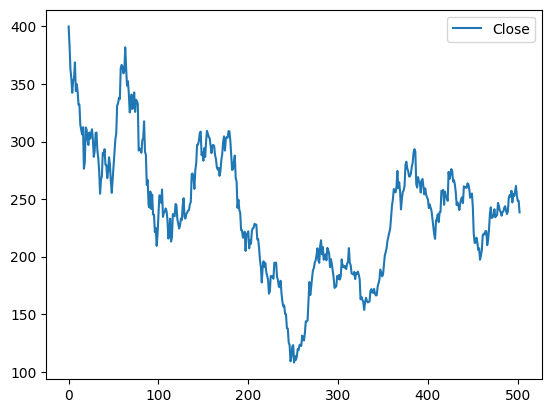

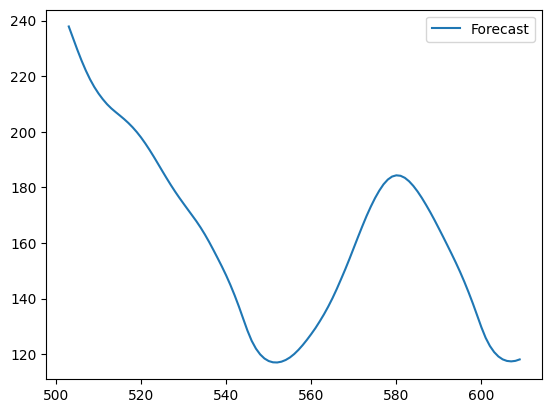

In [157]:
df.plot()
forecast_df.plot()

## **Joining Pandas Plots**

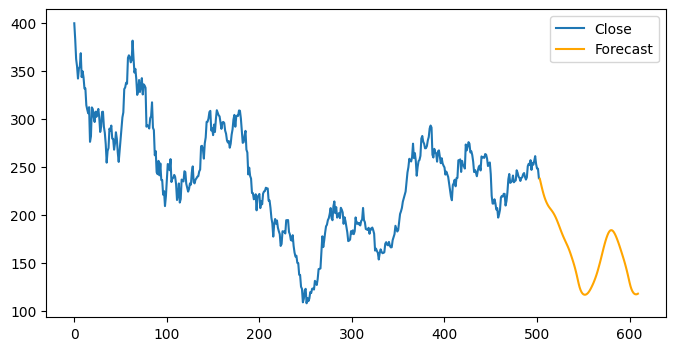

In [158]:
# Create DataFrame for the forecast
forecast_df = pd.DataFrame({'Forecast': forecast}, index=forecast_index)

# Plot historical and forecast data
ax = df['Close'].plot(figsize=(8, 4), label='Close')  # Historical data
forecast_df.plot(ax=ax, label='Forecast', color='orange')  # Forecasted data
plt.legend()
plt.show()

         Date      Close    Volume       Open       High        Low
0  02-01-2022  $310.4166  73138357  $311.7366  $314.5666  $301.6666
1  03-01-2022  $288.1233  74766877  $289.8933  $296.6266  $284.5933
2  04-01-2022    $361.53  54263225  $360.3833  $364.9166  $355.5466
3  06-01-2022    $246.79  77247968    $251.72  $257.3266    $243.64
4  07-01-2022  $227.2633  74460457    $227.00    $230.23    $222.12


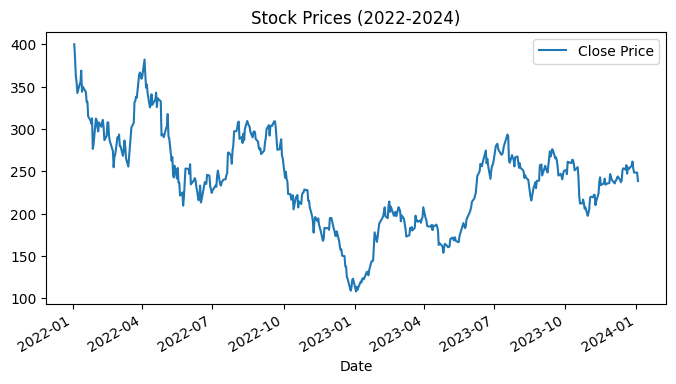

In [159]:
dir_path_dataset = 'TSLA_HistoricalData_2022_2024_V5.csv'
df = pd.read_csv(dir_path_dataset)

# Inspecting the dataset
print(df.head())

df.replace({'\$': ''}, regex=True, inplace=True)

df[['Close', 'Open', 'High', 'Low']] = df[['Close', 'Open', 'High', 'Low']].astype(float)

# Standardize the Date column
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Sort
df.sort_values(by="Date", inplace=True)

# reset the indexx after sorting
df.reset_index(drop=True, inplace=True)

# Keep only the first 503 rows
df = df.iloc[:503]

# Check the updated dataframe size
#print(len(df))

# Filtering relevant columns (only 'Date' and 'Close')
df = df.loc[:, ['Date', 'Close']]

# Converting 'Date' to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Filtering data for specific time period (if required)
#start_date = '2022-04-26'  # Adjust to your dataset's date range
#end_date = '2024-04-25'
#df_filtered = df.loc[start_date:end_date]

df_filtered=df

# Plotting the filtered data
df_filtered['Close'].plot(figsize=(8,4), title='Stock Prices (2022-2024)', label='Close Price')
plt.legend()
plt.show()


In [160]:
forecast_df['Forecast'].values

array([237.86562 , 233.7017  , 229.53944 , 225.62741 , 222.05202 ,
       218.86377 , 216.10968 , 213.74533 , 211.70216 , 209.90504 ,
       208.39996 , 207.09634 , 205.84969 , 204.56505 , 203.17015 ,
       201.61963 , 199.87321 , 197.92715 , 195.77182 , 193.44737 ,
       190.98709 , 188.42601 , 185.83917 , 183.29366 , 180.82796 ,
       178.47278 , 176.24098 , 174.1057  , 171.99901 , 169.91295 ,
       167.80797 , 165.52237 , 163.03377 , 160.34344 , 157.4753  ,
       154.52379 , 151.50719 , 148.31992 , 144.8711  , 141.1346  ,
       137.09352 , 132.77406 , 128.49135 , 124.79843 , 121.982475,
       119.89819 , 118.43568 , 117.51672 , 117.06455 , 117.00322 ,
       117.291855, 117.90335 , 118.821655, 120.047005, 121.546394,
       123.27229 , 125.180504, 127.226326, 129.39348 , 131.79948 ,
       134.34593 , 137.1249  , 140.14227 , 143.43637 , 146.94545 ,
       150.53311 , 154.31258 , 158.23076 , 162.15504 , 165.98366 ,
       169.67386 , 173.0573  , 176.137   , 178.82524 , 181.100

In [161]:
forecast_df['Forecast']

503    237.865616
504    233.701706
505    229.539444
506    225.627411
507    222.052017
          ...    
605    118.125069
606    117.563423
607    117.397598
608    117.585472
609    118.100632
Name: Forecast, Length: 107, dtype: float32

            Close    Forecast
2024-05-27    NaN  118.125069
2024-05-28    NaN  117.563423
2024-05-29    NaN  117.397598
2024-05-30    NaN  117.585472
2024-05-31    NaN  118.100632


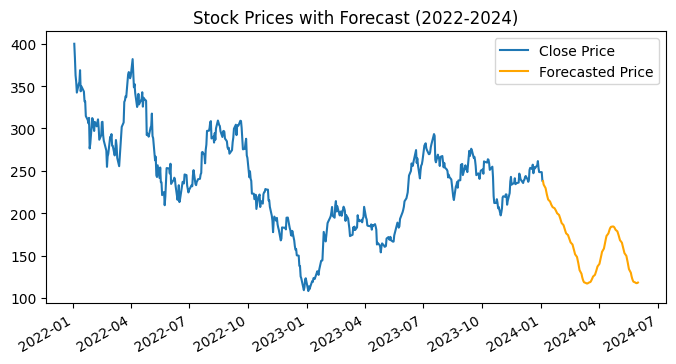

In [162]:
# Extending df_filtered to include forecasted dates
future_dates = pd.date_range(start=df_filtered.index[-1] + pd.Timedelta(days=1), periods=len(forecast), freq='B')
df_extended = df_filtered.reindex(df_filtered.index.union(future_dates))

# Adding the Forecast column
df_extended['Forecast'] = None  # Initialize a blank Forecast column
df_extended.loc[future_dates, 'Forecast'] = forecast  # Adding forecasted values to the new dates

# Inspect the result
print(df_extended.tail())

# Plot the data
ax = df_extended['Close'].plot(figsize=(8,4), label='Close Price')  # Historical prices
df_extended['Forecast'].plot(ax=ax, label='Forecasted Price', color='orange')  # Forecasted values
plt.legend()
plt.title("Stock Prices with Forecast (2022-2024)")
plt.show()
